# Stage 11 — Explanation Stability Analysis

## 1. Objective

The objective of Stage 11 is to evaluate the stability of SHAP-based explanations across different random validation configurations.

Stage 10 established global and local SHAP explanations for the Logistic Regression model.

However, a single SHAP analysis does not determine whether the identified important features are stable.

Therefore, Stage 11 investigates whether feature importance rankings remain reasonably consistent across different random seeds and cross-validation folds.

The primary research question is:

> Do the model's feature explanations remain stable across different training and validation configurations?

---

## 2. Dataset

The experiment uses the UCI Bank Marketing dataset:

`bank-full.csv`

The target variable is:

`y`

where:

- `0` = no term-deposit subscription
- `1` = term-deposit subscription

---

## 3. Model

The evaluated model is Logistic Regression with:

`class_weight="balanced"`

The preprocessing pipeline consists of:

- StandardScaler for numerical features
- OneHotEncoder for categorical features
- Logistic Regression classifier

The preprocessing pipeline is independently fitted within each training fold.

---

## 4. Experimental Design

The original dataset is divided into an 80% training set and a 20% test set using stratification and `random_state=42`.

The fixed test set is not used during explanation stability analysis.

The training data is evaluated using:

- 5 random seeds
- 3 stratified folds per seed

Therefore:

5 seeds × 3 folds = 15 SHAP experiments.

---

## 5. SHAP Sampling

To control computational cost, up to 500 validation observations are randomly selected from each validation fold for SHAP analysis.

The random sample is controlled using the corresponding experiment seed.

The same sampling strategy is applied consistently across experiments.

---

## 6. SHAP Importance

For every fold, SHAP values are calculated for the transformed feature representation.

The mean absolute SHAP value is then calculated for every transformed feature.

This provides a measure of the average magnitude of each feature's contribution to the model predictions.

---

## 7. Feature Ranking

Features are ranked according to their mean absolute SHAP values.

A lower numerical rank indicates a feature with greater mean SHAP importance.

The ranking is calculated separately for each experiment.

The rankings are then compared across the 15 experiments.

---

## 8. Top-10 Feature Overlap

Top-10 feature overlap evaluates whether the same features repeatedly appear among the ten most important features.

Jaccard similarity is used to compare the top-10 feature sets between pairs of experiments.

The Jaccard similarity is calculated as:

`Intersection / Union`

A value closer to 1 indicates greater overlap between the compared feature sets.

A value closer to 0 indicates less overlap.

---

## 9. Spearman Rank Correlation

Spearman rank correlation evaluates whether feature importance rankings are ordered similarly across experiments.

Unlike top-10 overlap, Spearman correlation considers the ranking of all shared features rather than only membership in the top ten.

The resulting correlations are summarized using their mean and standard deviation.

---

## 10. Feature Importance Variability

For each feature, the following statistics are calculated across the 15 experiments:

- Mean SHAP importance
- Standard deviation
- Minimum SHAP importance
- Maximum SHAP importance
- Coefficient of variation

These statistics allow the magnitude and stability of feature importance to be examined together.

---

## 11. Top-10 Frequency

The number of experiments in which each feature appears in the top ten is calculated.

This provides another measure of explanation consistency.

A feature appearing repeatedly in the top ten demonstrates repeated importance under the tested experimental configurations.

However, repeated appearance should not be interpreted as proof of causal importance.

---

## 12. Research Interpretation

Explanation stability should be interpreted using multiple measurements:

1. Mean absolute SHAP importance
2. SHAP standard deviation
3. Top-10 feature overlap
4. Jaccard similarity
5. Spearman rank correlation
6. Top-10 appearance frequency

No single metric completely describes explanation stability.

---

## 13. Important Limitation

Stability across five random seeds and three folds does not prove universal explanation stability.

It only provides evidence about stability under the experimental configurations evaluated in this study.

Different datasets, preprocessing methods, models, sampling strategies, or deployment populations could produce different explanations.

---

## 14. Causal Interpretation Limitation

SHAP explains the behavior of the trained machine-learning model.

It does not establish that a feature causes a customer to subscribe to a term deposit.

Therefore, SHAP importance should be interpreted as model attribution rather than causal influence.

---

## 15. Relationship to Stage 10

Stage 10 answered:

> Which features influence the model's predictions?

Stage 11 asks:

> Are those feature explanations stable across different validation configurations?

Together, the two stages provide a stronger XAI evaluation.

---

## 16. Relationship to the Overall Research Framework

The complete experimental framework now contains:

1. Data understanding
2. Exploratory data analysis
3. Leakage-safe preprocessing
4. Baseline classification
5. Imbalance strategies
6. Hyperparameter optimization
7. Multi-objective hyperparameter optimization
8. Threshold optimization
9. Robustness analysis
10. SHAP explainability
11. Explanation stability

This allows model performance, optimization behavior, robustness, and interpretability to be studied together.

---

## 17. Saved Outputs

The following files are generated:

`../results/shap/shap_stability_fold_results.csv`

Contains SHAP importance values for every feature across every seed/fold experiment.

`../results/shap/shap_stability_feature_summary.csv`

Contains mean, standard deviation, minimum, maximum, and coefficient of variation of feature-level SHAP importance.

`../results/shap/shap_top10_overlap.csv`

Contains pairwise top-10 feature overlap measurements.

`../results/shap/shap_spearman_stability.csv`

Contains pairwise Spearman rank correlations.

`../results/shap/shap_top10_frequency.csv`

Contains the frequency with which each feature appears in the top ten.

`../results/shap/shap_stability_summary.csv`

Contains the overall explanation stability statistics.

---

## 18. Research Question Answered

Stage 11 investigates:

> Are the explanations produced by the model consistent across different random training and validation configurations?

The final conclusion must be based on the actual measured overlap, rank correlation, and feature-level variability obtained from the experiment.

---

## 19. Stage 11 Conclusion

Stage 11 extends the XAI component from a single explanation into a systematic explanation-stability analysis.

The resulting measurements provide evidence about the reproducibility and consistency of the model's feature attribution patterns under the tested experimental configurations.

In [10]:
# ============================================================
# CELL 1 — INSTALL REQUIRED PACKAGES
# ============================================================

%pip install -U shap scikit-learn pandas numpy plotly scipy

Defaulting to user installation because normal site-packages is not writeable
  Using cached numpy-2.5.3-cp313-cp313-win_amd64.whl.metadata (6.6 kB)
Note: you may need to restart the kernel to use updated packages.


In [11]:
# ============================================================
# CELL 2 — IMPORT LIBRARIES
# ============================================================

import os
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import shap

import plotly.express as px
import plotly.graph_objects as go

from scipy.stats import spearmanr

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

from sklearn.linear_model import LogisticRegression

print("Libraries imported successfully.")
print("SHAP version:", shap.__version__)

Libraries imported successfully.
SHAP version: 0.52.0


In [12]:
# ============================================================
# CELL 3 — LOAD DATASET
# ============================================================

data_path = "../data/raw/bank-full.csv"

df = pd.read_csv(data_path)

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

display(df.head())

Dataset loaded successfully!
Dataset shape: (45211, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,18,student,single,primary,no,1944,no,no,telephone,10,aug,122,3,-1,0,unknown,no
1,18,student,single,unknown,no,108,no,no,cellular,10,aug,167,1,-1,0,unknown,yes
2,18,student,single,primary,no,608,no,no,cellular,12,aug,267,1,-1,0,unknown,yes
3,18,student,single,unknown,no,35,no,no,telephone,21,aug,104,2,-1,0,unknown,no
4,18,student,single,secondary,no,5,no,no,cellular,24,aug,143,2,-1,0,unknown,no


In [13]:
# ============================================================
# CELL 4 — SEPARATE FEATURES AND TARGET
# ============================================================

X = df.drop(columns=["y"])

y = df["y"].map({
    "no": 0,
    "yes": 1
})

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

display(y.value_counts())

Feature shape: (45211, 16)
Target shape: (45211,)


y
0    39922
1     5289
Name: count, dtype: int64

In [14]:
# ============================================================
# CELL 5 — IDENTIFY FEATURE TYPES
# ============================================================

numeric_columns = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_columns = X.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numeric features:")
print(numeric_columns)

print("\nCategorical features:")
print(categorical_columns)

Numeric features:
['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

Categorical features:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']


In [15]:
# ============================================================
# CELL 6 — FIXED TRAIN / TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

print("\nTraining class distribution:")
display(y_train.value_counts())

print("\nTesting class distribution:")
display(y_test.value_counts())

Training samples: 36168
Testing samples: 9043

Training class distribution:


y
0    31937
1     4231
Name: count, dtype: int64


Testing class distribution:


y
0    7985
1    1058
Name: count, dtype: int64

In [16]:
# ============================================================
# CELL 7 — RANDOM SEEDS
# ============================================================

random_seeds = [
    42,
    7,
    21,
    52,
    100
]

print("Random seeds:", random_seeds)
print("Number of seeds:", len(random_seeds))

Random seeds: [42, 7, 21, 52, 100]
Number of seeds: 5


In [17]:
# ============================================================
# CELL 8 — DEFINE SHAP SAMPLE SIZE
# ============================================================

SHAP_SAMPLE_SIZE = 500

print(
    "Maximum SHAP observations per fold:",
    SHAP_SAMPLE_SIZE
)

Maximum SHAP observations per fold: 500


fold
 ↓
preprocessing
 ↓
Logistic Regression
 ↓
SHAP
 ↓
mean absolute SHAP

In [18]:
# ============================================================
# CELL 9 — DEFINE SHAP STABILITY FUNCTION
# ============================================================

def calculate_fold_shap_importance(
    X_fold_train,
    y_fold_train,
    X_fold_valid,
    random_seed,
    fold_number,
    shap_sample_size=500
):
    
    preprocessor = ColumnTransformer(
        transformers=[
            (
                "numeric",
                StandardScaler(),
                numeric_columns
            ),
            (
                "categorical",
                OneHotEncoder(
                    handle_unknown="ignore"
                ),
                categorical_columns
            )
        ]
    )
    
    model = Pipeline(
        steps=[
            (
                "preprocessor",
                preprocessor
            ),
            (
                "classifier",
                LogisticRegression(
                    max_iter=1000,
                    class_weight="balanced",
                    random_state=random_seed
                )
            )
        ]
    )
    
    model.fit(
        X_fold_train,
        y_fold_train
    )
    
    fitted_preprocessor = (
        model.named_steps["preprocessor"]
    )
    
    classifier = (
        model.named_steps["classifier"]
    )
    
    # --------------------------------------------------------
    # SAMPLE VALIDATION DATA FOR SHAP
    # --------------------------------------------------------
    
    sample_size = min(
        shap_sample_size,
        len(X_fold_valid)
    )
    
    X_shap = X_fold_valid.sample(
        n=sample_size,
        random_state=random_seed
    )
    
    # --------------------------------------------------------
    # TRANSFORM DATA
    # --------------------------------------------------------
    
    X_shap_transformed = (
        fitted_preprocessor.transform(
            X_shap
        )
    )
    
    if hasattr(
        X_shap_transformed,
        "toarray"
    ):
        X_shap_dense = (
            X_shap_transformed.toarray()
        )
    else:
        X_shap_dense = (
            X_shap_transformed
        )
    
    feature_names = (
        fitted_preprocessor
        .get_feature_names_out()
    )
    
    X_shap_df = pd.DataFrame(
        X_shap_dense,
        columns=feature_names
    )
    
    # --------------------------------------------------------
    # SHAP
    # --------------------------------------------------------
    
    explainer = shap.LinearExplainer(
        classifier,
        X_shap_df
    )
    
    shap_values = explainer(
        X_shap_df
    )
    
    mean_absolute_shap = (
        np.abs(
            shap_values.values
        ).mean(axis=0)
    )
    
    result = pd.DataFrame({
        "Feature": feature_names,
        "Mean_Absolute_SHAP": mean_absolute_shap
    })
    
    result["Random_Seed"] = random_seed
    result["Fold"] = fold_number
    
    return result

5 seeds × 3 folds = 15 SHAP experiments

In [20]:
# ============================================================
# CELL 10 — RUN SHAP STABILITY EXPERIMENT
# ============================================================

all_shap_results = []

for seed in random_seeds:
    
    print("=" * 60)
    print(f"Running random seed: {seed}")
    print("=" * 60)
    
    cv = StratifiedKFold(
        n_splits=3,
        shuffle=True,
        random_state=seed
    )
    
    for fold_number, (
        train_idx,
        valid_idx
    ) in enumerate(
        cv.split(X_train, y_train),
        start=1
    ):
        
        print(
            f"  Processing fold {fold_number}..."
        )
        
        X_fold_train = X_train.iloc[
            train_idx
        ]
        
        X_fold_valid = X_train.iloc[
            valid_idx
        ]
        
        y_fold_train = y_train.iloc[
            train_idx
        ]
        
        fold_result = (
            calculate_fold_shap_importance(
                X_fold_train=X_fold_train,
                y_fold_train=y_fold_train,
                X_fold_valid=X_fold_valid,
                random_seed=seed,
                fold_number=fold_number,
                shap_sample_size=SHAP_SAMPLE_SIZE
            )
        )
        
        all_shap_results.append(
            fold_result
        )

shap_stability_results = pd.concat(
    all_shap_results,
    ignore_index=True
)

print("\nSHAP stability experiment completed.")

print(
    "Total SHAP result rows:",
    len(shap_stability_results)
)

display(
    shap_stability_results.head(20)
)

Background dataset has 500 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=500 when initializing the masker.


Running random seed: 42
  Processing fold 1...
  Processing fold 2...


Background dataset has 500 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=500 when initializing the masker.
Background dataset has 500 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=500 when initializing the masker.


  Processing fold 3...
Running random seed: 7
  Processing fold 1...


Background dataset has 500 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=500 when initializing the masker.
Background dataset has 500 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=500 when initializing the masker.


...

Background dataset has 500 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=500 when initializing the masker.
Background dataset has 500 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=500 when initializing the masker.


Running random seed: 100
  Processing fold 1...
  Processing fold 2...


Background dataset has 500 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=500 when initializing the masker.
Background dataset has 500 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=500 when initializing the masker.


  Processing fold 3...

SHAP stability experiment completed.
Total SHAP result rows: 765


,Feature,Mean_Absolute_SHAP,Random_Seed,Fold
0,numeric__age,0.009031,42,1
1,numeric__balance,0.031170,42,1
2,numeric__day,0.006924,42,1
3,numeric__duration,1.080698,42,1
4,numeric__campaign,0.177026,42,1
5,numeric__pdays,0.015321,42,1
6,numeric__previous,0.032184,42,1
7,categorical__job_admin.,0.041117,42,1
8,categorical__job_blue-collar,0.048053,42,1
9,categorical__job_entrepreneur,0.017759,42,1


In [21]:
# ============================================================
# CELL 11 — VALIDATE SHAP STABILITY EXPERIMENT
# ============================================================

print("=" * 80)
print("SHAP STABILITY EXPERIMENT VALIDATION")
print("=" * 80)

expected_experiments = (
    len(random_seeds) * 3
)

actual_experiments = (
    shap_stability_results[
        ["Random_Seed", "Fold"]
    ]
    .drop_duplicates()
    .shape[0]
)

print(
    "Expected SHAP experiments:",
    expected_experiments
)

print(
    "Actual SHAP experiments:",
    actual_experiments
)

assert (
    actual_experiments
    == expected_experiments
)

assert (
    shap_stability_results[
        "Feature"
    ].notna().all()
)

assert (
    shap_stability_results[
        "Mean_Absolute_SHAP"
    ].notna().all()
)

assert (
    shap_stability_results[
        "Mean_Absolute_SHAP"
    ] >= 0
).all()

print("\n✓ Five seeds evaluated.")
print("✓ Three folds per seed.")
print("✓ 15 SHAP experiments completed.")
print("✓ SHAP importance values are valid.")

SHAP STABILITY EXPERIMENT VALIDATION
Expected SHAP experiments: 15
Actual SHAP experiments: 15

✓ Five seeds evaluated.
✓ Three folds per seed.
✓ 15 SHAP experiments completed.
✓ SHAP importance values are valid.


In [22]:
# ============================================================
# CELL 12 — AGGREGATE SHAP IMPORTANCE
# ============================================================

shap_feature_summary = (
    shap_stability_results
    .groupby("Feature")[
        "Mean_Absolute_SHAP"
    ]
    .agg(
        Mean="mean",
        Std="std",
        Min="min",
        Max="max"
    )
    .reset_index()
)

shap_feature_summary[
    "Coefficient_of_Variation"
] = (
    shap_feature_summary["Std"]
    /
    shap_feature_summary["Mean"]
)

shap_feature_summary = (
    shap_feature_summary
    .sort_values(
        "Mean",
        ascending=False
    )
    .reset_index(drop=True)
)

print("=" * 80)
print("SHAP STABILITY SUMMARY")
print("=" * 80)

display(
    shap_feature_summary
    .head(20)
    .round(5)
)

SHAP STABILITY SUMMARY


,Feature,Mean,Std,Min,Max,Coefficient_of_Variation
0,numeric__duration,1.02938,0.07472,0.89779,1.19675,0.07259
1,categorical__contact_unknown,0.43948,0.03137,0.38112,0.49352,0.07137
2,categorical__month_may,0.28814,0.01682,0.25067,0.31299,0.05838
3,categorical__month_jul,0.25534,0.03976,0.20140,0.35883,0.15573
4,categorical__contact_cellular,0.25255,0.01906,0.21671,0.28302,0.07548
5,categorical__poutcome_unknown,0.25150,0.02444,0.19777,0.30419,0.09719
6,categorical__housing_yes,0.20078,0.01176,0.17786,0.22179,0.05857
7,categorical__month_aug,0.19444,0.02686,0.15443,0.22632,0.13813
8,categorical__housing_no,0.19269,0.01623,0.16433,0.23126,0.08425
9,numeric__campaign,0.18495,0.02294,0.14250,0.22024,0.12401


In [23]:
# ============================================================
# CELL 13 — FEATURE RANKING
# ============================================================

shap_feature_summary[
    "Mean_SHAP_Rank"
] = (
    shap_feature_summary[
        "Mean"
    ]
    .rank(
        ascending=False,
        method="average"
    )
)

print("=" * 80)
print("TOP SHAP FEATURES WITH RANKS")
print("=" * 80)

display(
    shap_feature_summary
    .head(20)
    .round(4)
)

TOP SHAP FEATURES WITH RANKS


,Feature,Mean,Std,Min,Max,Coefficient_of_Variation,Mean_SHAP_Rank
0,numeric__duration,1.0294,0.0747,0.8978,1.1967,0.0726,1.0
1,categorical__contact_unknown,0.4395,0.0314,0.3811,0.4935,0.0714,2.0
2,categorical__month_may,0.2881,0.0168,0.2507,0.3130,0.0584,3.0
3,categorical__month_jul,0.2553,0.0398,0.2014,0.3588,0.1557,4.0
4,categorical__contact_cellular,0.2526,0.0191,0.2167,0.2830,0.0755,5.0
5,categorical__poutcome_unknown,0.2515,0.0244,0.1978,0.3042,0.0972,6.0
6,categorical__housing_yes,0.2008,0.0118,0.1779,0.2218,0.0586,7.0
7,categorical__month_aug,0.1944,0.0269,0.1544,0.2263,0.1381,8.0
8,categorical__housing_no,0.1927,0.0162,0.1643,0.2313,0.0842,9.0
9,numeric__campaign,0.1850,0.0229,0.1425,0.2202,0.1240,10.0


In [24]:
# ============================================================
# CELL 14 — TOP-10 FEATURE OVERLAP
# ============================================================

top_n = 10

experiment_rankings = []

for (seed, fold), group in (
    shap_stability_results
    .groupby(["Random_Seed", "Fold"])
):
    
    ranking = (
        group
        .sort_values(
            "Mean_Absolute_SHAP",
            ascending=False
        )
        .head(top_n)
        ["Feature"]
        .tolist()
    )
    
    experiment_rankings.append({
        "Random_Seed": seed,
        "Fold": fold,
        "Top_Features": ranking
    })

top10_overlap_records = []

for i in range(
    len(experiment_rankings)
):
    
    for j in range(
        i + 1,
        len(experiment_rankings)
    ):
        
        first = experiment_rankings[i]
        second = experiment_rankings[j]
        
        first_set = set(
            first["Top_Features"]
        )
        
        second_set = set(
            second["Top_Features"]
        )
        
        intersection = (
            first_set
            .intersection(second_set)
        )
        
        union = (
            first_set
            .union(second_set)
        )
        
        jaccard_similarity = (
            len(intersection)
            /
            len(union)
        )
        
        top10_overlap_records.append({
            "Seed_1": first["Random_Seed"],
            "Fold_1": first["Fold"],
            "Seed_2": second["Random_Seed"],
            "Fold_2": second["Fold"],
            "Common_Features": len(intersection),
            "Jaccard_Similarity": jaccard_similarity
        })

top10_overlap_df = pd.DataFrame(
    top10_overlap_records
)

print("=" * 80)
print("TOP-10 SHAP FEATURE OVERLAP")
print("=" * 80)

display(
    top10_overlap_df.head(20).round(4)
)

TOP-10 SHAP FEATURE OVERLAP


,Seed_1,Fold_1,Seed_2,Fold_2,Common_Features,Jaccard_Similarity
0,7,1,7,2,9,0.8182
1,7,1,7,3,9,0.8182
2,7,1,21,1,9,0.8182
3,7,1,21,2,10,1.0000
4,7,1,21,3,9,0.8182
5,7,1,42,1,9,0.8182
6,7,1,42,2,9,0.8182
7,7,1,42,3,9,0.8182
8,7,1,52,1,9,0.8182
9,7,1,52,2,10,1.0000


In [25]:
# ============================================================
# CELL 15 — AVERAGE TOP-10 OVERLAP
# ============================================================

mean_top10_jaccard = (
    top10_overlap_df[
        "Jaccard_Similarity"
    ]
    .mean()
)

mean_common_features = (
    top10_overlap_df[
        "Common_Features"
    ]
    .mean()
)

print("=" * 80)
print("AVERAGE TOP-10 SHAP STABILITY")
print("=" * 80)

print(
    f"Average common features: "
    f"{mean_common_features:.4f}"
)

print(
    f"Average Jaccard similarity: "
    f"{mean_top10_jaccard:.4f}"
)

AVERAGE TOP-10 SHAP STABILITY
Average common features: 9.3048
Average Jaccard similarity: 0.8742


0 → no overlap
1 → identical sets

In [27]:
# ============================================================
# CELL 16 — SPEARMAN RANK CORRELATION
# ============================================================

pivot_importance = (
    shap_stability_results
    .pivot_table(
        index="Feature",
        columns=[
            "Random_Seed",
            "Fold"
        ],
        values="Mean_Absolute_SHAP"
    )
)

spearman_records = []

experiment_columns = (
    pivot_importance.columns.tolist()
)

for i in range(
    len(experiment_columns)
):
    
    for j in range(
        i + 1,
        len(experiment_columns)
    ):
        
        col1 = experiment_columns[i]
        col2 = experiment_columns[j]
        
        paired_data = (
            pivot_importance[
                [col1, col2]
            ]
            .dropna()
        )
        
        correlation, p_value = spearmanr(
            paired_data[col1],
            paired_data[col2]
        )
        
        spearman_records.append({
            "Seed_1": col1[0],
            "Fold_1": col1[1],
            "Seed_2": col2[0],
            "Fold_2": col2[1],
            "Spearman_Correlation": correlation,
            "P_Value": p_value
        })

spearman_df = pd.DataFrame(
    spearman_records
)

print("=" * 80)
print("SHAP RANK CORRELATION")
print("=" * 80)

display(
    spearman_df.head(20).round(4)
)

SHAP RANK CORRELATION


,Seed_1,Fold_1,Seed_2,Fold_2,Spearman_Correlation,P_Value
0,7,1,7,2,0.9369,0.0
1,7,1,7,3,0.8957,0.0
2,7,1,21,1,0.9287,0.0
3,7,1,21,2,0.9452,0.0
4,7,1,21,3,0.8884,0.0
5,7,1,42,1,0.9128,0.0
6,7,1,42,2,0.9071,0.0
7,7,1,42,3,0.9217,0.0
8,7,1,52,1,0.9214,0.0
9,7,1,52,2,0.9185,0.0


In [28]:
# ============================================================
# CELL 17 — AVERAGE SPEARMAN CORRELATION
# ============================================================

mean_spearman = (
    spearman_df[
        "Spearman_Correlation"
    ]
    .mean()
)

std_spearman = (
    spearman_df[
        "Spearman_Correlation"
    ]
    .std()
)

print("=" * 80)
print("SPEARMAN SHAP RANK STABILITY")
print("=" * 80)

print(
    f"Mean Spearman correlation: "
    f"{mean_spearman:.4f}"
)

print(
    f"Standard deviation: "
    f"{std_spearman:.4f}"
)

SPEARMAN SHAP RANK STABILITY
Mean Spearman correlation: 0.9132
Standard deviation: 0.0204


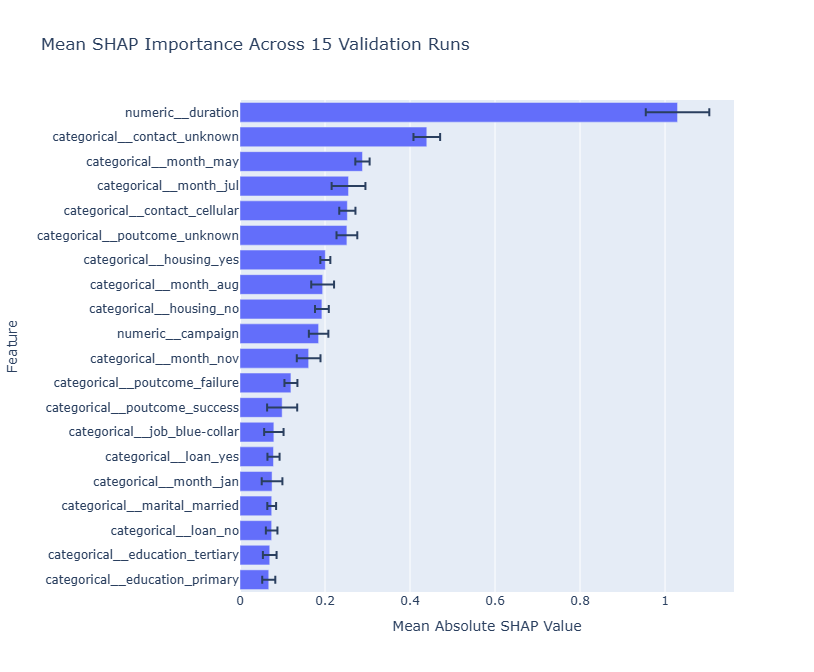

In [29]:
# ============================================================
# CELL 18 — MEAN SHAP IMPORTANCE WITH VARIABILITY
# ============================================================

plot_data = (
    shap_feature_summary
    .head(20)
    .sort_values(
        "Mean",
        ascending=True
    )
)

fig = go.Figure()

fig.add_trace(
    go.Bar(
        x=plot_data["Mean"],
        y=plot_data["Feature"],
        orientation="h",
        error_x=dict(
            type="data",
            array=plot_data["Std"],
            visible=True
        ),
        name="Mean |SHAP|"
    )
)

fig.update_layout(
    title="Mean SHAP Importance Across 15 Validation Runs",
    xaxis_title="Mean Absolute SHAP Value",
    yaxis_title="Feature",
    width=950,
    height=650
)

fig.show()

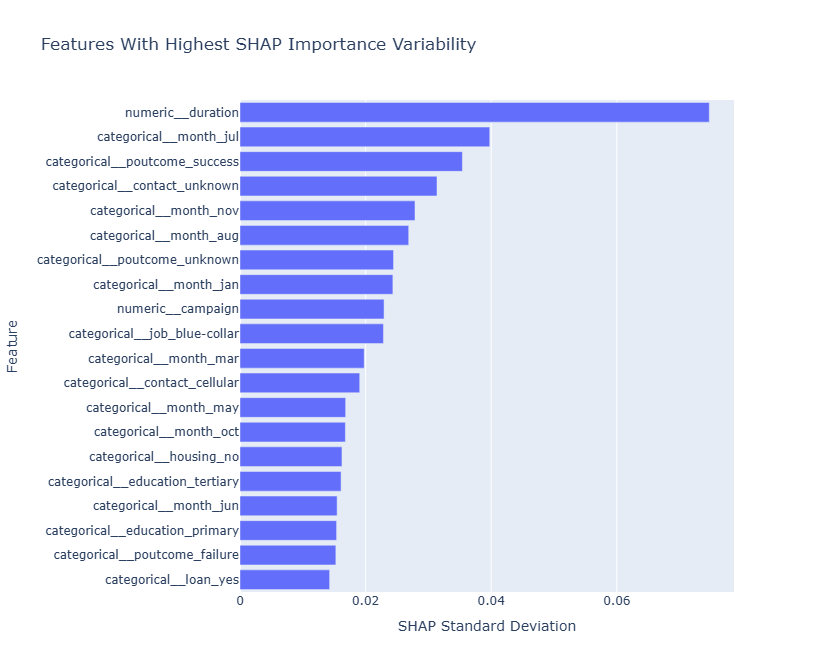

In [30]:
# ============================================================
# CELL 19 — SHAP IMPORTANCE VARIABILITY
# ============================================================

variability_data = (
    shap_feature_summary
    .sort_values(
        "Std",
        ascending=False
    )
    .head(20)
    .sort_values(
        "Std",
        ascending=True
    )
)

fig = px.bar(
    variability_data,
    x="Std",
    y="Feature",
    orientation="h",
    title="Features With Highest SHAP Importance Variability",
    labels={
        "Std": "SHAP Standard Deviation",
        "Feature": "Feature"
    },
    hover_data=[
        "Mean",
        "Min",
        "Max",
        "Coefficient_of_Variation"
    ]
)

fig.update_layout(
    width=900,
    height=650
)

fig.show()

In [31]:
# ============================================================
# CELL 20 — TOP-10 APPEARANCE FREQUENCY
# ============================================================

top10_frequency = {}

for ranking in experiment_rankings:
    
    for feature in ranking["Top_Features"]:
        
        top10_frequency[feature] = (
            top10_frequency.get(
                feature,
                0
            ) + 1
        )

top10_frequency_df = pd.DataFrame({
    "Feature": list(
        top10_frequency.keys()
    ),
    "Top_10_Count": list(
        top10_frequency.values()
    )
})

total_experiments = (
    len(experiment_rankings)
)

top10_frequency_df[
    "Top_10_Frequency_Percentage"
] = (
    top10_frequency_df[
        "Top_10_Count"
    ]
    /
    total_experiments
    * 100
)

top10_frequency_df = (
    top10_frequency_df
    .sort_values(
        "Top_10_Count",
        ascending=False
    )
    .reset_index(drop=True)
)

print("=" * 80)
print("TOP-10 FEATURE APPEARANCE FREQUENCY")
print("=" * 80)

display(
    top10_frequency_df
    .head(20)
    .round(4)
)

TOP-10 FEATURE APPEARANCE FREQUENCY


,Feature,Top_10_Count,Top_10_Frequency_Percentage
0,numeric__duration,15,100.0000
1,categorical__contact_unknown,15,100.0000
2,categorical__month_may,15,100.0000
3,categorical__poutcome_unknown,15,100.0000
4,categorical__contact_cellular,15,100.0000
5,categorical__month_jul,15,100.0000
6,categorical__housing_yes,15,100.0000
7,categorical__housing_no,14,93.3333
8,numeric__campaign,14,93.3333
9,categorical__month_aug,10,66.6667


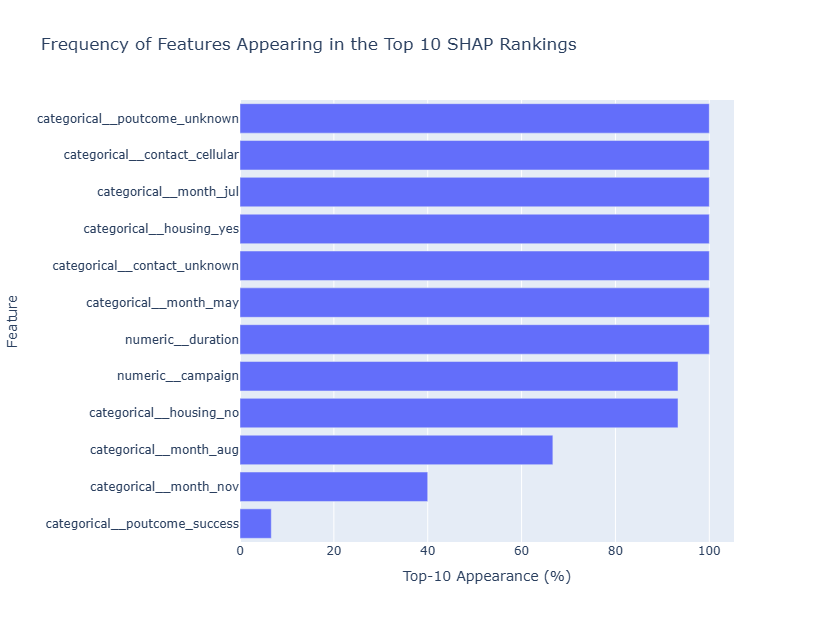

In [32]:
# ============================================================
# CELL 21 — TOP-10 FEATURE FREQUENCY
# ============================================================

frequency_plot = (
    top10_frequency_df
    .head(15)
    .sort_values(
        "Top_10_Frequency_Percentage"
    )
)

fig = px.bar(
    frequency_plot,
    x="Top_10_Frequency_Percentage",
    y="Feature",
    orientation="h",
    title="Frequency of Features Appearing in the Top 10 SHAP Rankings",
    labels={
        "Top_10_Frequency_Percentage":
            "Top-10 Appearance (%)",
        "Feature":
            "Feature"
    },
    hover_data=[
        "Top_10_Count"
    ]
)

fig.update_layout(
    width=900,
    height=600
)

fig.show()

In [33]:
# ============================================================
# CELL 22 — SAVE FOLD-LEVEL SHAP RESULTS
# ============================================================

os.makedirs(
    "../results/shap",
    exist_ok=True
)

fold_shap_path = (
    "../results/shap/"
    "shap_stability_fold_results.csv"
)

shap_stability_results.to_csv(
    fold_shap_path,
    index=False
)

print(
    "Fold-level SHAP results saved:"
)

print(fold_shap_path)

Fold-level SHAP results saved:
../results/shap/shap_stability_fold_results.csv


In [34]:
# ============================================================
# CELL 23 — SAVE SHAP FEATURE SUMMARY
# ============================================================

feature_summary_path = (
    "../results/shap/"
    "shap_stability_feature_summary.csv"
)

shap_feature_summary.to_csv(
    feature_summary_path,
    index=False
)

print(
    "SHAP feature stability summary saved:"
)

print(feature_summary_path)

SHAP feature stability summary saved:
../results/shap/shap_stability_feature_summary.csv


In [35]:
# ============================================================
# CELL 24 — SAVE TOP-10 OVERLAP RESULTS
# ============================================================

top10_overlap_path = (
    "../results/shap/"
    "shap_top10_overlap.csv"
)

top10_overlap_df.to_csv(
    top10_overlap_path,
    index=False
)

print(
    "Top-10 overlap results saved:"
)

print(top10_overlap_path)

Top-10 overlap results saved:
../results/shap/shap_top10_overlap.csv


In [36]:
# ============================================================
# CELL 25 — SAVE SPEARMAN RESULTS
# ============================================================

spearman_path = (
    "../results/shap/"
    "shap_spearman_stability.csv"
)

spearman_df.to_csv(
    spearman_path,
    index=False
)

print(
    "Spearman stability results saved:"
)

print(spearman_path)

Spearman stability results saved:
../results/shap/shap_spearman_stability.csv


In [37]:
# ============================================================
# CELL 26 — SAVE TOP-10 FREQUENCY
# ============================================================

frequency_path = (
    "../results/shap/"
    "shap_top10_frequency.csv"
)

top10_frequency_df.to_csv(
    frequency_path,
    index=False
)

print(
    "Top-10 feature frequency saved:"
)

print(frequency_path)

Top-10 feature frequency saved:
../results/shap/shap_top10_frequency.csv


In [38]:
# ============================================================
# CELL 27 — CREATE OVERALL STABILITY SUMMARY
# ============================================================

stability_summary = pd.DataFrame({
    "Number_of_Seeds": [
        len(random_seeds)
    ],
    "Folds_Per_Seed": [
        3
    ],
    "Total_SHAP_Experiments": [
        len(experiment_rankings)
    ],
    "SHAP_Sample_Size_Per_Fold": [
        SHAP_SAMPLE_SIZE
    ],
    "Top_10_Mean_Common_Features": [
        mean_common_features
    ],
    "Top_10_Mean_Jaccard": [
        mean_top10_jaccard
    ],
    "Mean_Spearman_Correlation": [
        mean_spearman
    ],
    "Std_Spearman_Correlation": [
        std_spearman
    ]
})

print("=" * 80)
print("OVERALL SHAP STABILITY SUMMARY")
print("=" * 80)

display(
    stability_summary.round(4)
)

OVERALL SHAP STABILITY SUMMARY


,Number_of_Seeds,Folds_Per_Seed,Total_SHAP_Experiments,SHAP_Sample_Size_Per_Fold,Top_10_Mean_Common_Features,Top_10_Mean_Jaccard,Mean_Spearman_Correlation,Std_Spearman_Correlation
0,5,3,15,500,9.3048,0.8742,0.9132,0.0204


In [39]:
# ============================================================
# CELL 28 — SAVE OVERALL STABILITY SUMMARY
# ============================================================

overall_summary_path = (
    "../results/shap/"
    "shap_stability_summary.csv"
)

stability_summary.to_csv(
    overall_summary_path,
    index=False
)

print(
    "Overall SHAP stability summary saved:"
)

print(overall_summary_path)

Overall SHAP stability summary saved:
../results/shap/shap_stability_summary.csv


In [40]:
# ============================================================
# CELL 29 — STAGE 11 FINAL VALIDATION
# ============================================================

print("=" * 80)
print("STAGE 11 FINAL VALIDATION")
print("=" * 80)

assert len(random_seeds) == 5

assert (
    len(experiment_rankings)
    == 15
)

assert (
    actual_experiments
    == 15
)

assert len(
    shap_feature_summary
) > 0

assert len(
    top10_overlap_df
) > 0

assert len(
    spearman_df
) > 0

assert os.path.exists(
    "../results/shap/"
    "shap_stability_fold_results.csv"
)

assert os.path.exists(
    "../results/shap/"
    "shap_stability_feature_summary.csv"
)

assert os.path.exists(
    "../results/shap/"
    "shap_top10_overlap.csv"
)

assert os.path.exists(
    "../results/shap/"
    "shap_spearman_stability.csv"
)

assert os.path.exists(
    "../results/shap/"
    "shap_top10_frequency.csv"
)

assert os.path.exists(
    "../results/shap/"
    "shap_stability_summary.csv"
)

print("✓ Five random seeds evaluated.")
print("✓ Three folds per seed.")
print("✓ 15 SHAP experiments completed.")
print("✓ Mean SHAP importance calculated.")
print("✓ SHAP feature ranks calculated.")
print("✓ Top-10 overlap calculated.")
print("✓ Spearman rank stability calculated.")
print("✓ Feature frequency calculated.")
print("✓ All required output files saved.")

print("\nSTAGE 11 COMPLETED SUCCESSFULLY.")

STAGE 11 FINAL VALIDATION
✓ Five random seeds evaluated.
✓ Three folds per seed.
✓ 15 SHAP experiments completed.
✓ Mean SHAP importance calculated.
✓ SHAP feature ranks calculated.
✓ Top-10 overlap calculated.
✓ Spearman rank stability calculated.
✓ Feature frequency calculated.
✓ All required output files saved.

STAGE 11 COMPLETED SUCCESSFULLY.


                    MODEL PERFORMANCE
                           │
             ┌─────────────┴─────────────┐
             ↓                           ↓
       Stage 6 HPO                 Stage 9 Robustness
             │                           │
             ↓                           ↓
       Optimization                 Performance
        effectiveness                 stability
             │                           │
             └─────────────┬─────────────┘
                           ↓
                     Stage 10 SHAP
                           │
                           ↓
                  Model explanations
                           │
                           ↓
                 Stage 11 Stability
                           │
                           ↓
              Explanation reliability